In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.getcwd())
tfrecordpath = "../Data/tfrecords/"


2025-02-05 15:57:09.484051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738767429.600854    8275 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738767429.634879    8275 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-05 15:57:09.924808: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/mnt/c/Users/alexs/Desktop/levbot/Training


### Load in data
#### Define schema


In [2]:
def decode(record_bytes):
    # Function for parsing each record in the tf files
    example = tf.io.parse_single_example(
        # Data
        record_bytes,

        # Schema
        {
        'Timeframe': tf.io.FixedLenFeature([], tf.string),
        'timestamp': tf.io.RaggedFeature(dtype=tf.int64),
        'Open': tf.io.RaggedFeature(dtype=tf.float32),
        'High': tf.io.RaggedFeature(dtype=tf.float32),
        'Low': tf.io.RaggedFeature(dtype=tf.float32),
        'Close': tf.io.RaggedFeature(dtype=tf.float32),
        'Volume': tf.io.RaggedFeature(dtype=tf.float32),
        }
        )

    return example

In [3]:
def getDataset(path):
    ds = tf.data.TFRecordDataset(path,  num_parallel_reads = tf.data.AUTOTUNE)
    ds = ds.map(decode, num_parallel_calls = tf.data.AUTOTUNE)
    return ds



In [4]:
import TensorSlider

In [118]:
windowsize = 100
lookahead = 5

def slider():


    path = tfrecordpath + "BTCUSD_PERP/{tframe}.tfrecord"
    datasets = {"1m" : getDataset(path.format(tframe="1m")),
                "5m":  getDataset(path.format(tframe="5m")),
                "15m":  getDataset(path.format(tframe="15m")),
                "30m":  getDataset(path.format(tframe="30m")),
                "1h":  getDataset(path.format(tframe="1h"))}
    return TensorSlider.WindowSlider(windowsize, lookahead, datasets)

dataset = tf.data.Dataset.from_generator(slider, 
    output_signature=(
        tf.TensorSpec((5,5,windowsize), dtype=tf.float32),
        tf.TensorSpec((lookahead+1,5), dtype=tf.float32))
    )

In [123]:
def createLabels(data, lookforward):
    """
    create input labels from the lookaehad data
    """
    
    ohlc = lookforward
    ohlc /= ohlc[0,:] # divide by open price
    ohlc -= 1 # zero out
    ohlc *= 100 # convert to 1/10 percentage
    
    high = ohlc[tf.math.argmin(ohlc[:,1]), 1]
    low = ohlc[tf.math.argmin(ohlc[:,2]), 2]

    # same process, compute relative deltas
    processed = []
    latestClose = data[0,3,0] # base timeframe
    pricemult = 10
    volmult = 1
    for i in range(0, data.shape[0]):
        # lets go timeframe by timeframe
        prices = tf.divide(data[i,0:4,:], latestClose) - 1
        prices = tf.multiply(prices, pricemult)
        volumes = tf.divide(data[i,4,:], data[i,4,0]) - 1
        volumes = tf.multiply(volumes, volmult)
        volumes = tf.expand_dims(volumes, 0)
        processed.append(tf.concat([prices, volumes], axis=0))

    datares = tf.clip_by_value(tf.stack(processed, axis=0), clip_value_min=-2, clip_value_max=2)

    return tf.expand_dims(datares,0), [low, high]
    
    


In [131]:
def printtimeframe(features):
    feet = features[0]
    print(feet.shape)
    for ft in feet:
        plt.plot(ft[4])
    plt.show()

Time taken for 2 calls: 0.030266284942626953s, thats 15.13ms per call
(5, 5, 100)


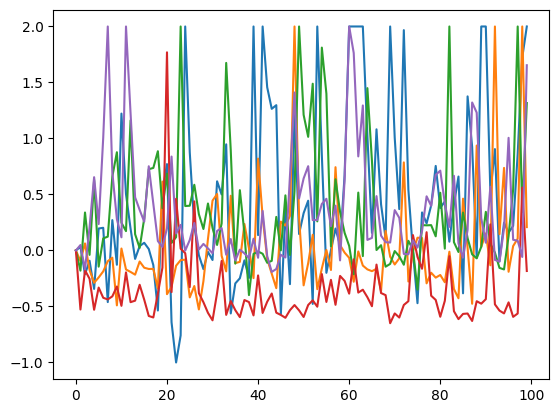

In [132]:
import time
t0 = None
for i, data in enumerate(dataset.map(createLabels)):
    if i == 0:
        t0 = time.time()
    if i > 0:
        tdelta = time.time() - t0
        print(f"Time taken for {i+1} calls: {tdelta}s, thats {((tdelta/(i+1))*1000):.2f}ms per call")
        printtimeframe(data[0])
        break
        

In [133]:
import keras
path = "models/modeltest/model.keras"
model = keras.models.load_model(path)
history = model.fit(dataset.map(createLabels),
                        epochs=1, verbose=1,
                        validation_data=None, callbacks=None)

    450/Unknown 14s 19ms/step - MeanAbsolutePercentageError: nan - MeanSquaredError: nan - loss: nan

KeyboardInterrupt: 